In [1]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

from scripts.final_manuscript.plot_settings import PlotKind, set_palette, set_style

set_palette(PlotKind.REACTION)
set_style()
sns.set_context("notebook")

In [12]:
original = pd.read_hdf("simulated_and_measured_gri3_highT.h5")
inert = pd.read_hdf("simulated_and_measured_inert_co2.h5", key="data_fixed_uncert")
mevel = pd.read_hdf("simulated_and_measured_mevel2015.h5", key="data_fixed_uncert")

In [13]:
original.head()

,diluent,phi_nom,dil_mf_nom,p_0,u_p_0,t_0,phi,u_phi,dil_mf,u_dil_mf,...,u_cell_size_measured,cell_size_gavrikov,cell_size_ng,cell_size_westbrook,cell_size_westbrook_2,gavrikov_criteria_met,znd_step,znd_end_time,znd_tries,znd_max_temp_time
0,CO2,0.4,0.10,101393.842884,2.307000,289.846188,0.419182,0.000208,0.103943,0.000040,...,0.480062,NaN,NaN,40.925134,364.312497,False,None,None,None,None
1,CO2,0.4,0.15,101400.200470,1.609842,290.021614,0.416662,0.000215,0.154795,0.000036,...,0.479481,NaN,NaN,76.639840,667.941320,False,None,None,None,None
2,CO2,0.4,0.20,101383.316513,1.976709,290.005443,0.425508,0.000378,0.207642,0.000063,...,0.594380,NaN,NaN,149.109836,1272.427132,False,None,None,None,None
3,CO2,0.7,0.10,101393.617108,2.121143,289.767941,0.735369,0.000243,0.104023,0.000045,...,0.530100,NaN,NaN,24.249279,225.067576,False,None,None,None,None
4,CO2,0.7,0.15,101412.528953,2.179424,289.308769,0.730354,0.000250,0.154600,0.000045,...,0.512883,NaN,NaN,43.235202,392.775812,False,None,None,None,None


In [14]:
inert.head()

,diluent,phi_nom,dil_mf_nom,p_0,u_p_0,t_0,phi,u_phi,dil_mf,u_dil_mf,...,u_cell_size_measured,cell_size_gavrikov,cell_size_ng,cell_size_westbrook,cell_size_westbrook_2,gavrikov_criteria_met,znd_step,znd_end_time,znd_tries,znd_max_temp_time
0,CO2i,0.4,0.10,101393.842884,2.307000,289.846188,0.419182,0.000208,0.103943,0.000040,...,0.480062,NaN,NaN,35.474659,317.045358,False,None,None,None,None
1,CO2i,0.4,0.15,101400.200470,1.609842,290.021614,0.416662,0.000215,0.154795,0.000036,...,0.479481,NaN,NaN,66.178538,579.282548,False,None,None,None,None
2,CO2i,0.4,0.20,101383.316513,1.976709,290.005443,0.425508,0.000378,0.207642,0.000063,...,0.594380,NaN,NaN,128.290329,1099.827448,False,None,None,None,None
3,CO2i,0.7,0.10,101393.617108,2.121143,289.767941,0.735369,0.000243,0.104023,0.000045,...,0.530100,NaN,NaN,20.419915,190.547978,False,None,None,None,None
4,CO2i,0.7,0.15,101412.528953,2.179424,289.308769,0.730354,0.000250,0.154600,0.000045,...,0.512883,NaN,NaN,35.551288,324.944241,False,None,None,None,None


In [15]:
plot_data = pd.DataFrame(columns=("mechanism", "diluent", "phi_nom", "dil_mf_nom", "cell_size"))
for dataset, title in ((original, "GRI3.0"), (inert, "GRI3.0 Inert CO2"), (mevel, "Mevel2015")):
    plot_data = pd.concat((
        plot_data,
        pd.DataFrame({
            "mechanism": title,
            "diluent": dataset["diluent"],
            "phi_nom": dataset["phi_nom"],
            "dil_mf_nom": dataset["dil_mf_nom"],
            "cell_size": dataset["cell_size_westbrook"],
        })
    ))
plot_data["diluent"] = ["CO2" if v == "CO2i" else v for v in plot_data["diluent"].values]
plot_data.reset_index(drop=True, inplace=True)

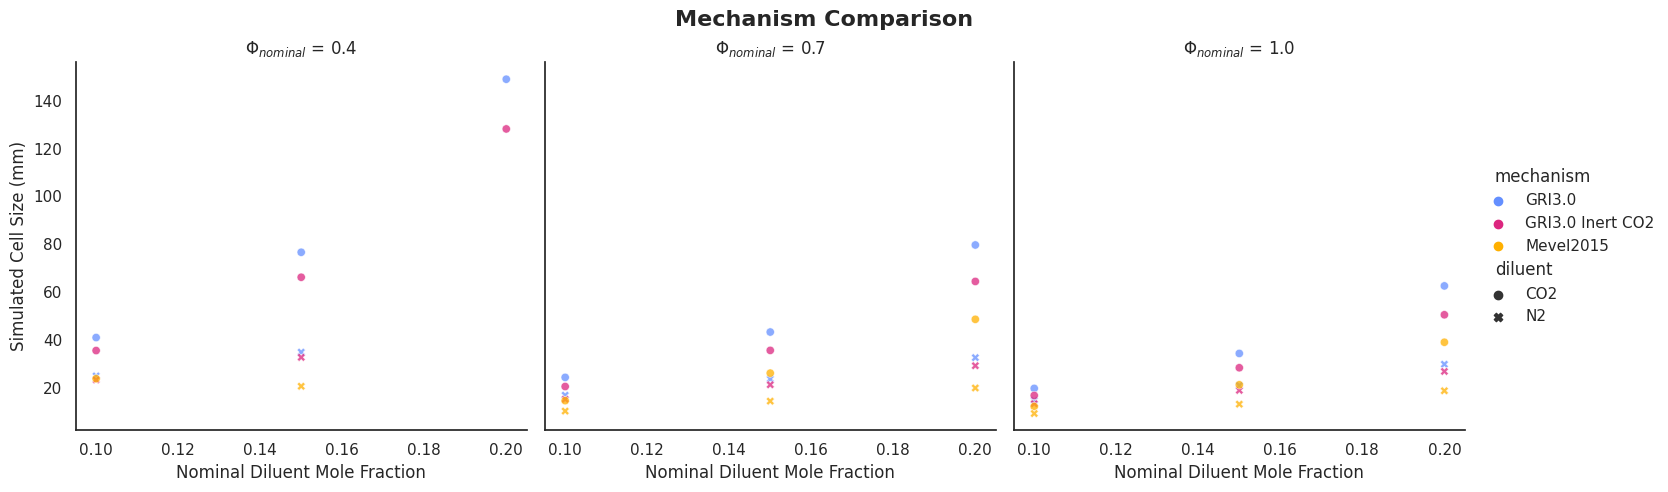

In [16]:
g = sns.relplot(
    data=plot_data,
    x="dil_mf_nom",
    y="cell_size",
    col="phi_nom",
    hue="mechanism",
    style="diluent",
    alpha=0.75,
)
g.set_xlabels("Nominal Diluent Mole Fraction")
g.set_ylabels("Simulated Cell Size (mm)")
for a in g.axes.flatten():
    a.set_title(a.title.get_text().replace("phi_nom", r"$\Phi_{nominal}$"))
g.figure.suptitle("Mechanism Comparison", size=16, weight="bold")
g.figure.subplots_adjust(top=0.875)

Conclusion: AFT matching is not a useful technique for isolating thermal and chemical effects for detonation simulations

# Answers to Blunck Feedback Questions

In [3]:
lfs = pd.read_hdf("../final_manuscript/laminar_flame_speeds_2024_09_21.h5")
lfs.head()

,diluent,phi_nom,dil_mf_nom,p_0,u_p_0,t_0,phi,u_phi,dil_mf,u_dil_mf,...,lfs,cp_initial,cv_initial,spec_heat_ratio_initial,cp_ps,cv_ps,spec_heat_ratio_ps,sound_speed,mach,mach_cj
0,CO2,0.4,0.10,101393.842884,2.307000,289.846188,0.419182,0.000208,0.103943,0.000040,...,0.199628,909.118916,709.421292,1.281494,1500.863916,1301.166292,1.153476,272.367992,6.535513,6.889700
1,CO2,0.4,0.15,101400.200470,1.609842,290.021614,0.416662,0.000215,0.154795,0.000036,...,0.155665,904.660319,705.664875,1.281997,1480.457610,1281.462166,1.155288,272.024420,6.405031,6.694242
2,CO2,0.4,0.20,101383.316513,1.976709,290.005443,0.425508,0.000378,0.207642,0.000063,...,0.125351,900.866749,702.342236,1.282661,1463.131532,1264.607019,1.156985,271.765114,6.185260,6.506339
3,CO2,0.7,0.10,101393.617108,2.121143,289.767941,0.735369,0.000243,0.104023,0.000045,...,0.465626,939.484944,732.249607,1.283012,1617.464194,1410.228857,1.146952,277.587660,7.004583,7.179177
4,CO2,0.7,0.15,101412.528953,2.179424,289.308769,0.730354,0.000250,0.154600,0.000045,...,0.374253,932.121944,726.122231,1.283698,1588.412108,1382.412394,1.149015,276.613521,6.813859,6.986906


### What are the measured detonation speeds and how does it change with dilution, etc and the 2 diluents?

Can we explain changes in detonation by changes in

1. Speed of sound: maybe

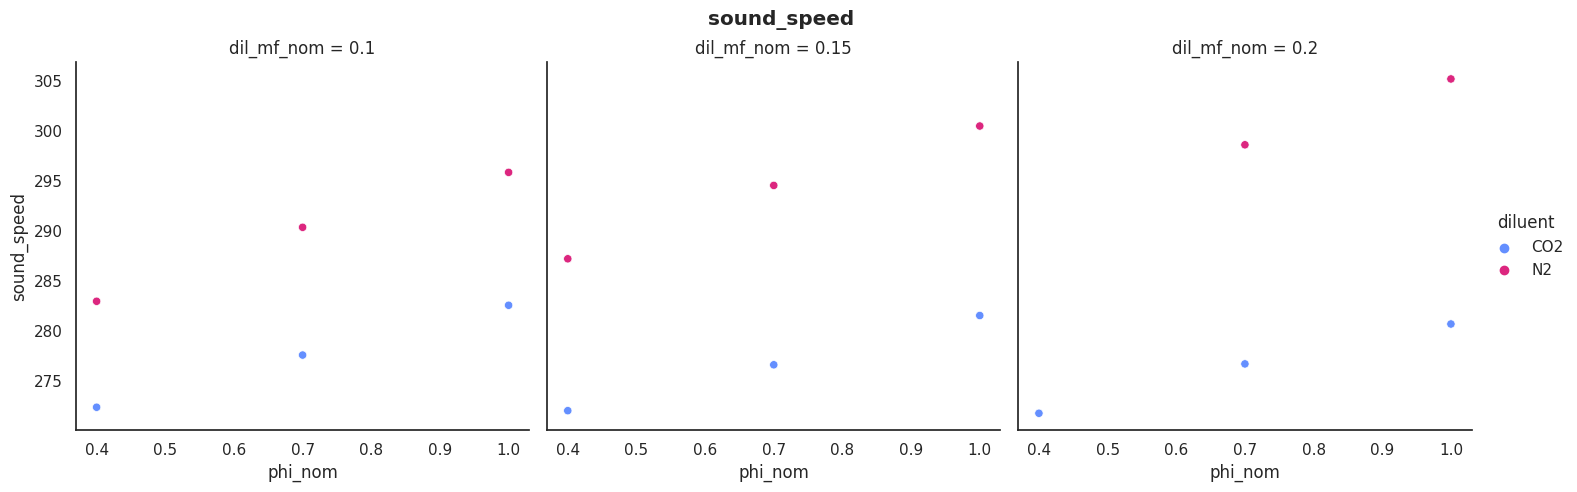

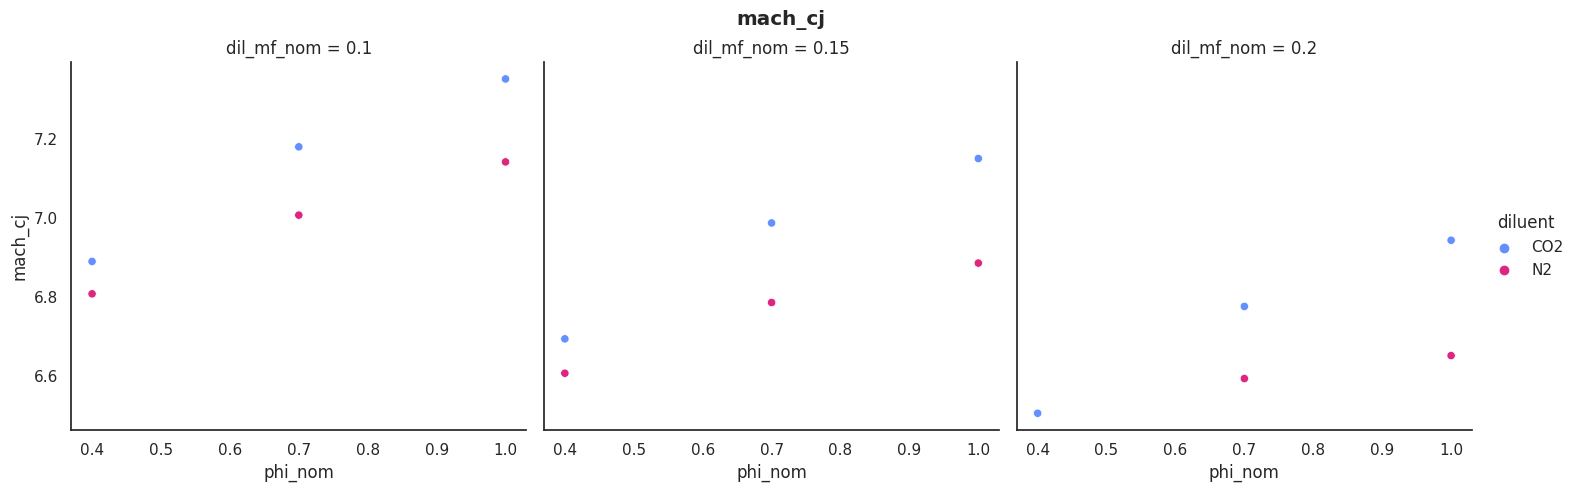

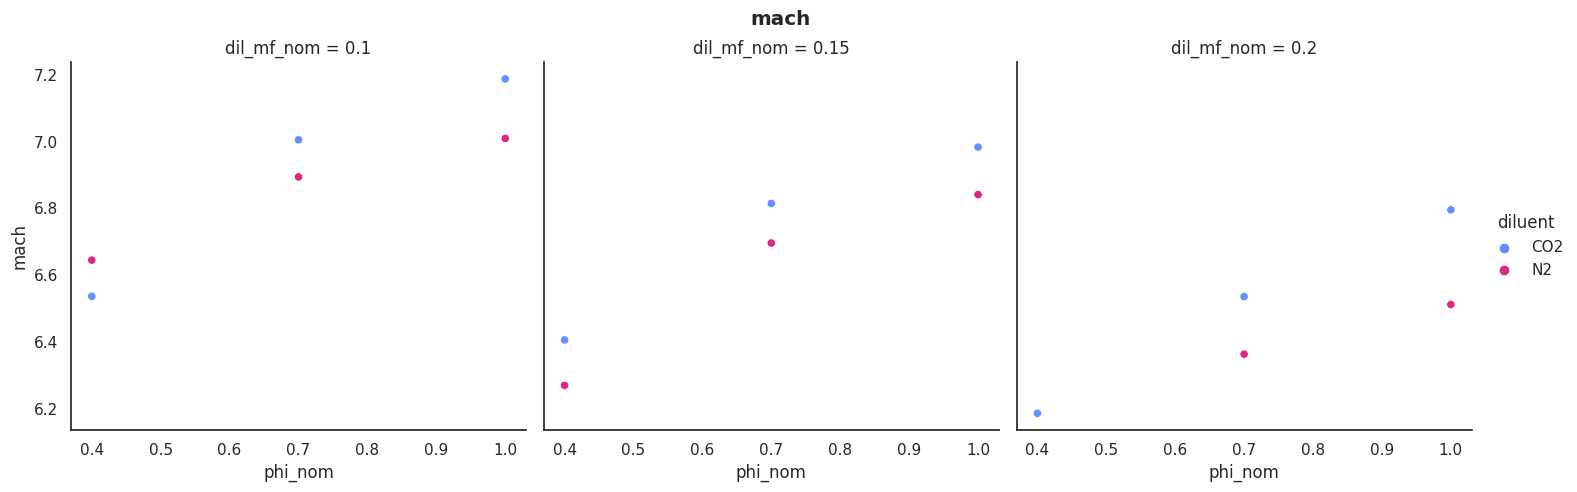

In [4]:
for y in ("sound_speed", "mach_cj", "mach"):
    sns.relplot(x="phi_nom", y=y, data=lfs, col="dil_mf_nom", hue="diluent")
    plt.suptitle(y, weight="bold")
    plt.subplots_adjust(top=0.875)

2. Changes in ratio of specific heats, etc.

At initial conditions: maybe

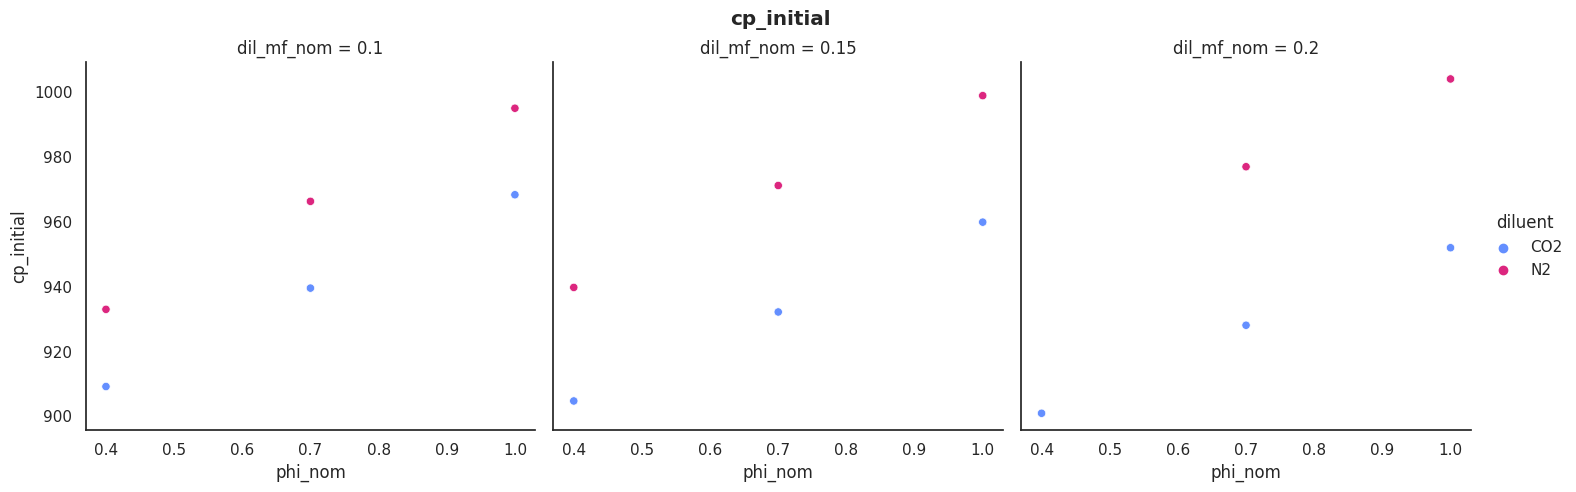

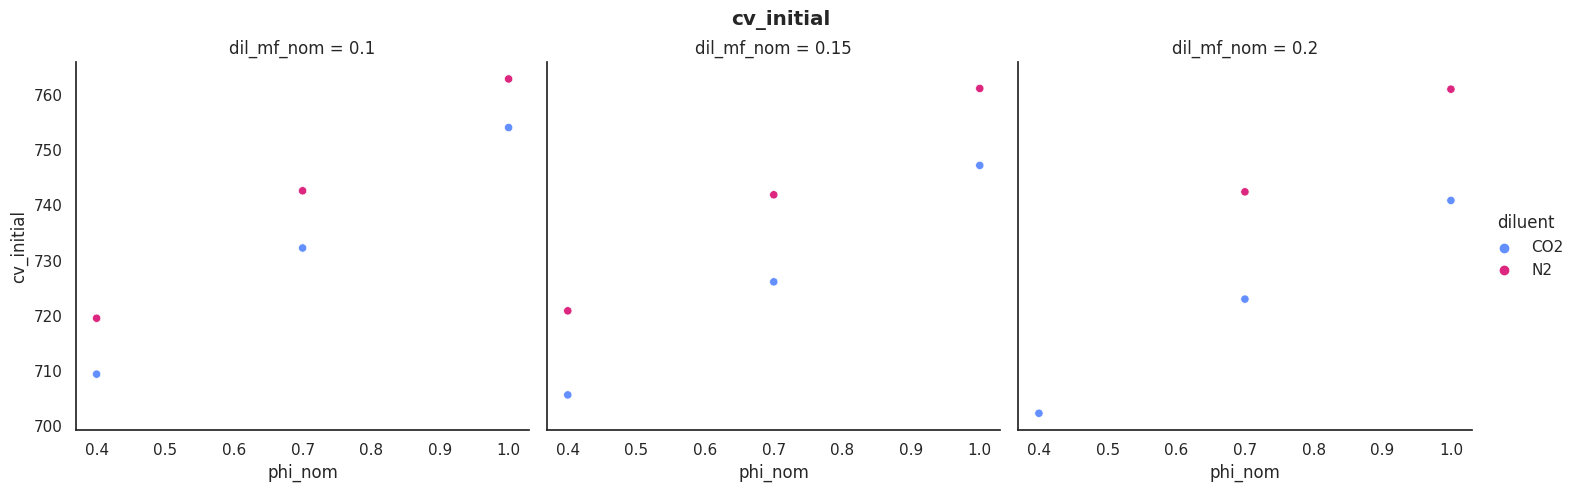

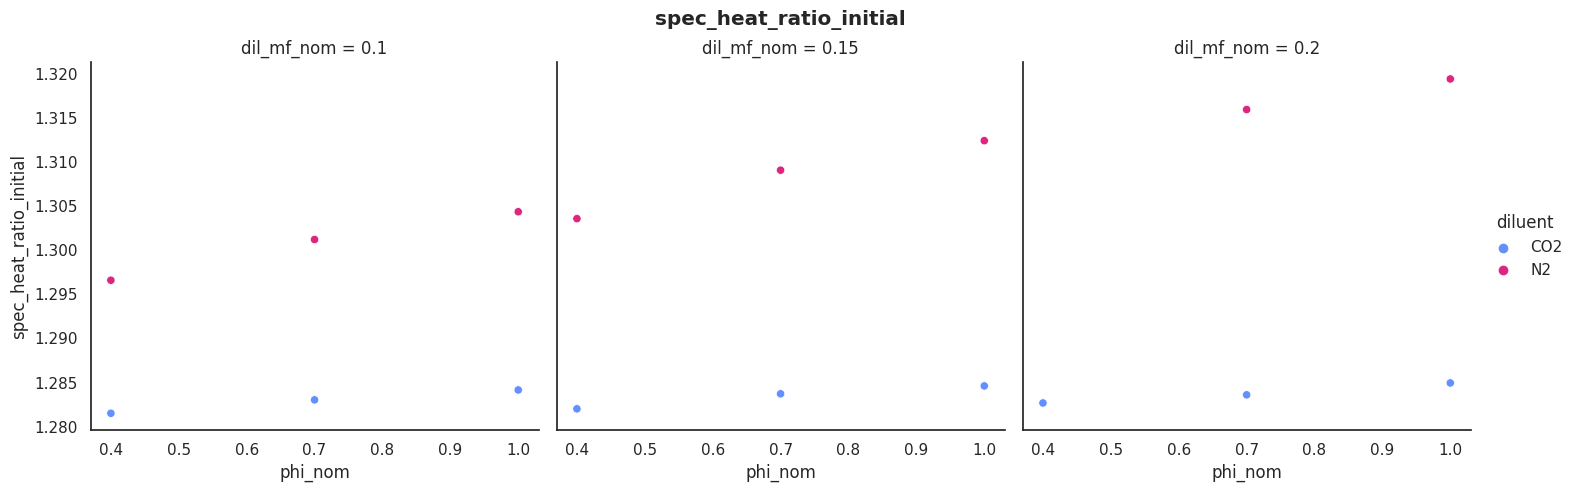

In [7]:
for y in ("cp_initial", "cv_initial", "spec_heat_ratio_initial"):
    sns.relplot(x="phi_nom", y=y, data=lfs, col="dil_mf_nom", hue="diluent")
    plt.suptitle(y, weight="bold")
    plt.subplots_adjust(top=0.875)

At post-shock (frozen) conditions: also maybe

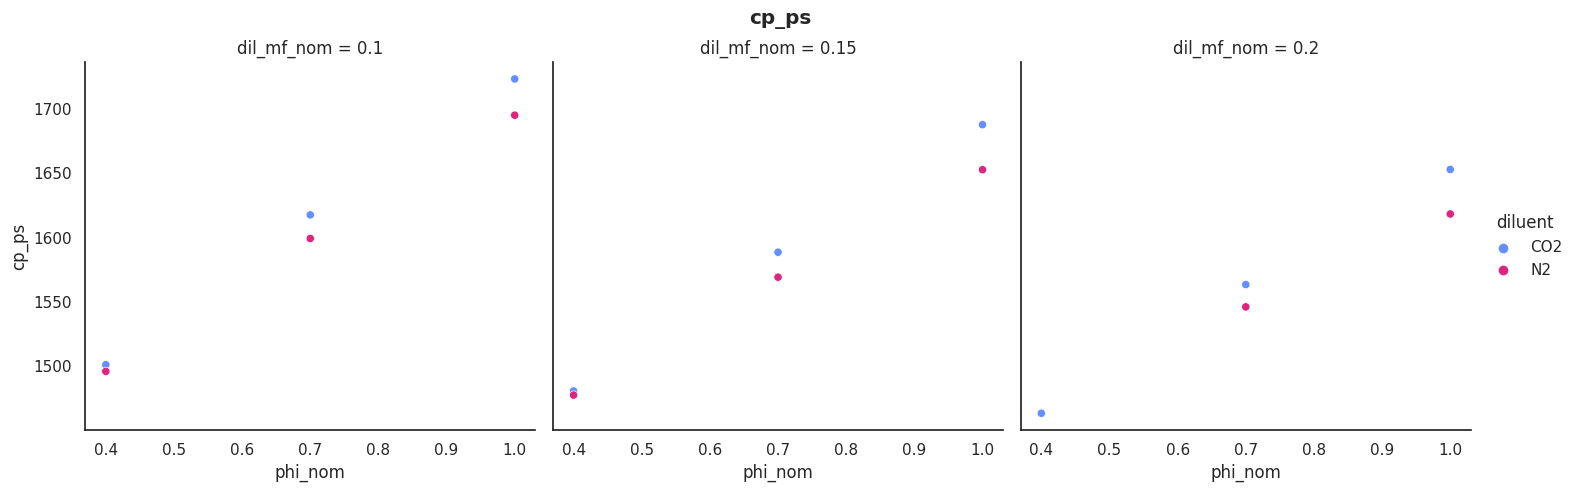

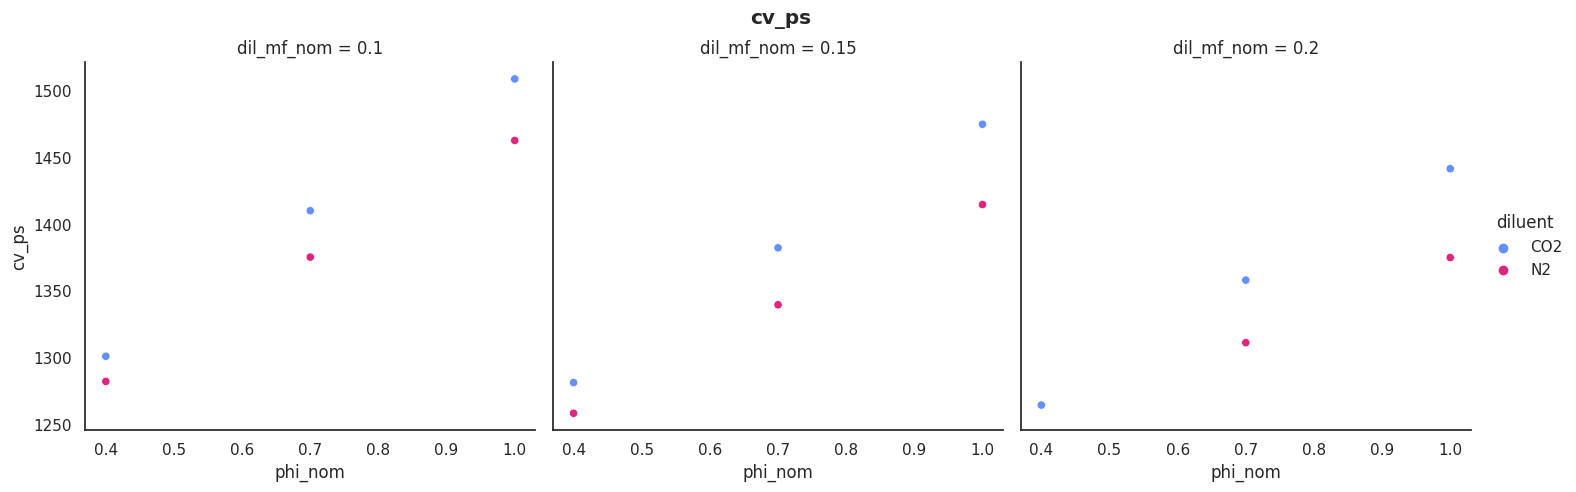

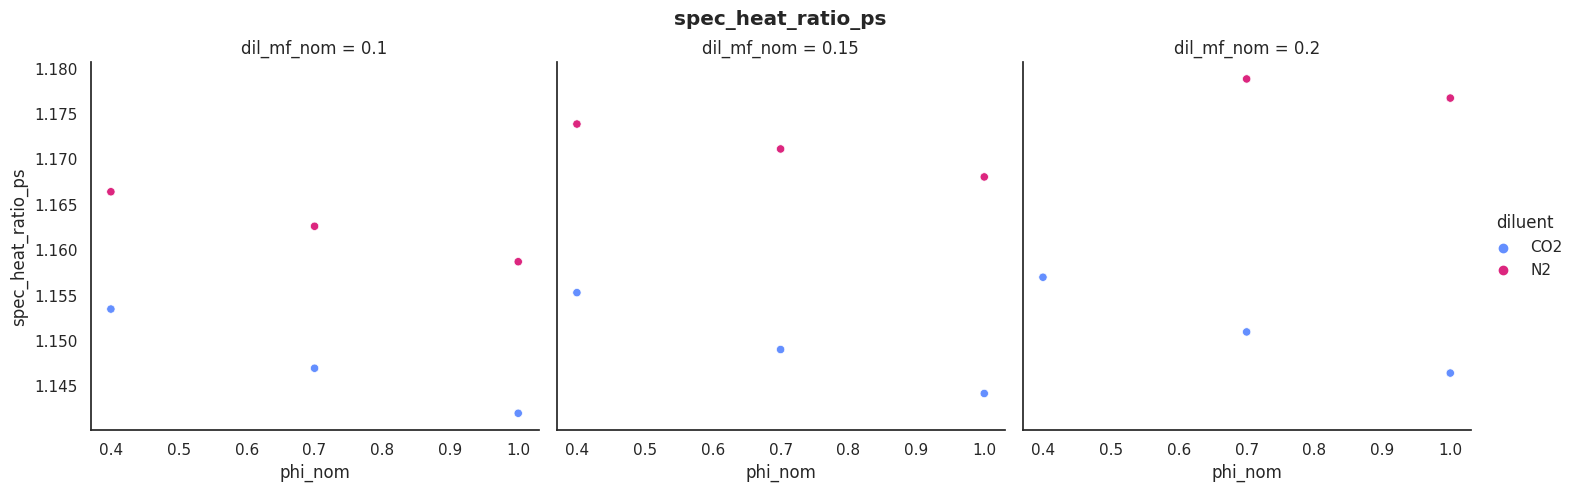

In [8]:
for y in ("cp_ps", "cv_ps", "spec_heat_ratio_ps"):
    sns.relplot(x="phi_nom", y=y, data=lfs, col="dil_mf_nom", hue="diluent")
    plt.suptitle(y, weight="bold")
    plt.subplots_adjust(top=0.875)

### What is the percent change between inert CO2 and non-inert CO2 results?

It seems to be about 15% or so.

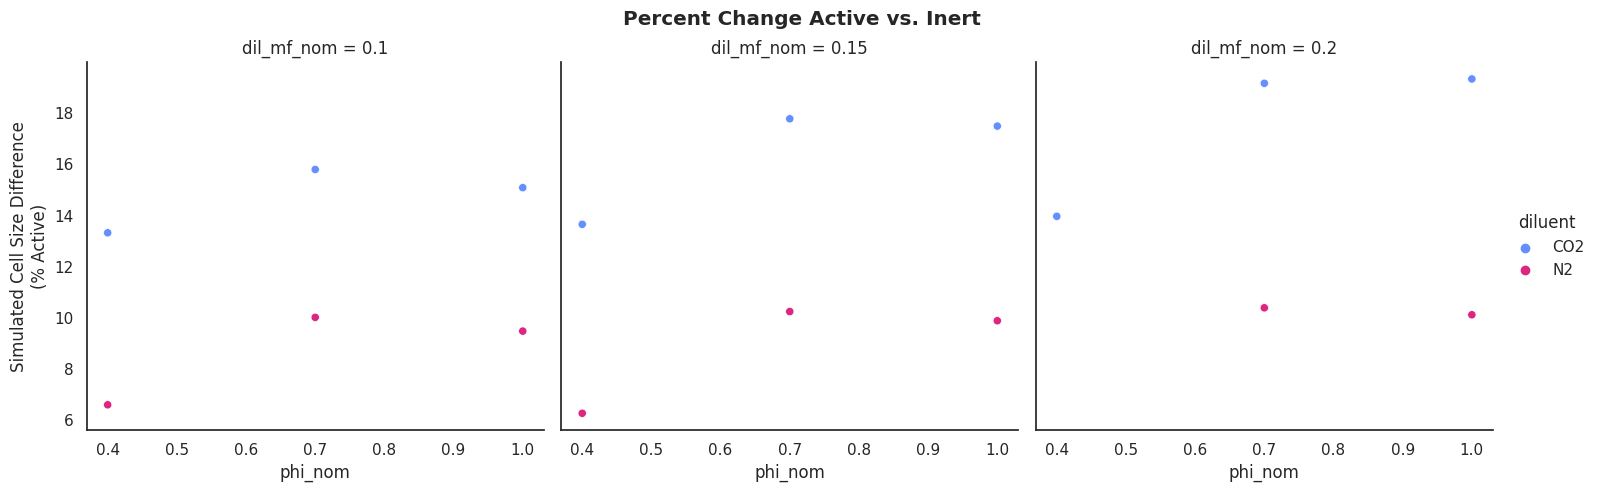

In [40]:
co2_active = plot_data[plot_data["mechanism"] == "GRI3.0"]\
    .copy()\
    .set_index(["diluent", "phi_nom", "dil_mf_nom"], drop=True)\
    .drop("mechanism", axis=1)
co2_inert = plot_data[plot_data["mechanism"].str.contains("Inert")]\
    .copy()\
    .set_index(["diluent", "phi_nom", "dil_mf_nom"], drop=True)\
    .drop("mechanism", axis=1)
inert_comparison = (100 * (co2_active - co2_inert) / co2_active).reset_index().rename(columns={"cell_size": "diff_pct"})
g = sns.relplot(x="phi_nom", y="diff_pct", data=inert_comparison, col="dil_mf_nom", hue="diluent")
g.figure.suptitle("Percent Change Active vs. Inert", weight="bold")
g.set_ylabels("Simulated Cell Size Difference\n(% Active)")
g.figure.subplots_adjust(top=0.875)

1. Does the percentage change with mole fraction?
    - Yes, and this appears to follow the approximate trend we saw with sim/meas where N2 and CO2 diverge with increasing dilution
2. Does the chemical sensitivity help to explain the sensitivity to diluent species with increasing mole fraction?
    - Likely not, or not fully (DB)
    - I'm inclined to lean towards not fully due to seeing the trend in cp/cv and sound speed (above)
        - It would probably be instructive to look at all of these as a percentage
        - WHAT DOES THIS PLOT MEAN, PHYSICALLY?
            - Percent difference in simulated cell sizes when diluted with CO2 vs. CO2i and N2 vs N2i
            - I don't know that comparing CO2 to N2 in this manner is helpful
3. Could it be that the time-scale for detonations is so fast that reactions associated with CO2 are different than predicted?
    - Possibly... I would need to think more about how we would look into that
4. Or could there be dissociation going on that alters CO2 interaction, etc?

### Some sensitivity to reactions from CO2 is noted because of the difference in results between inert and non-inert CO2

### TODO: THIS NEEDS MORE WORK

1. What reactions cause this sensitivity and what is happening?
2. Are there changes in H radical concentrations, etc.